In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [4]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')

/tmp/ipykernel_867904/2776969467.py:1: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


In [24]:
# Focus on 1 plate 1 light regime (2h-2h)(plate1)
plate = '99'
light = '2h-2h'
df = data[(data['plate'].astype(str)==plate)&(data['light_regime']==light)]

In [ ]:
from Scripts_Imane import Format_Data
data = Format_Data.get_format_data(data)

In [5]:
import os
import pandas as pd
import numpy as np

folder = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Design_Matrices/'
data = data.copy()

# Étape 1 : construire un dict pour stocker le fichier le plus récent par (plate, light)
latest_files = {}

for fname in os.listdir(folder):
    if not fname.endswith('.csv'):
        continue
    parts = fname.replace('.csv', '').split('_')
    if len(parts) < 3:
        continue

    try:
        file_date = pd.to_datetime(parts[0], format='%Y%m%d')
    except ValueError:
        continue

    plate_part = parts[1]  # ex: 99-M3
    light_part = '_'.join(parts[2:])  # ex: 20h_HL

    key = (plate_part, light_part)
    if key not in latest_files or file_date > latest_files[key][1]:
        latest_files[key] = (fname, file_date)

# Étape 2 : parcours des fichiers sélectionnés
for fname, _ in latest_files.values():
    for plate in data['plate'].unique():
        for light in data['light_regime'].unique():
            if (f"_{plate}-" in fname) and (light in fname):
                path = os.path.join(folder, fname)
                try:
                    dm = pd.read_csv(path, sep=';', encoding='utf-8')
                except UnicodeDecodeError:
                    dm = pd.read_csv(path, sep=';', encoding='latin1')

                if 'PAR' in dm.columns and 'No.' in dm.columns:
                    dm['light_status'] = np.where(dm['PAR'] > 0, 'light', 'dark')

                    # Filtrer les lignes concernées dans data
                    mask = (data['plate'].astype(str) == str(plate)) & (data['light_regime'] == light)

                    # Traiter chaque colonne de mesure
                    measurement_cols = [c for c in data.columns if c.startswith('measurement_time_')]
                    for col in measurement_cols:
                        no_col = str(int(col.replace('measurement_time_', '')) + 1)
                        light_status_col_name = f'light_status_{no_col}'

                        match = dm.loc[dm['No.'].astype(str) == no_col, 'light_status']
                        if not match.empty:
                            light_status = match.values[0]
                            data.loc[mask, light_status_col_name] = light_status
                        else:
                            print(f"Aucun match trouvé pour No. == {no_col} dans {fname}")


Aucun match trouvé pour No. == 47 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 48 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 49 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 50 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 51 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 52 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 53 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 54 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 55 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 56 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 57 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 58 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 59 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 60 dans 20240830_31v3-M3_20h_ML.csv
Aucun match trouvé pour No. == 61 dans 20240830_31v3-M3_20h_ML

In [22]:
folder = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Design_Matrices/'
for fname in os.listdir(folder):
    if (f"_{plate}-" in fname) and (light in fname):
        dm = pd.read_csv(os.path.join(folder, fname), sep=';')
        dm['Date'] = pd.to_datetime(dm['Date'], format='%d.%m.%y')
        

In [14]:
data

,Unnamed: 0,plate,measurement,start_date,light_regime,dark_threshold,light_threshold,num_frames,i,j,...,light_status_81,light_status_82,light_status_83,light_status_84,light_status_85,light_status_86,light_status_87,light_status_88,light_status_89,light_status_90
0,89817,99,M1,2024-05-19,1min-1min,27.346588,36.402420,180,0,5,...,dark,light,dark,light,dark,light,dark,light,dark,dark
1,90079,99,M1,2024-05-19,1min-1min,27.346588,36.402420,180,11,3,...,dark,light,dark,light,dark,light,dark,light,dark,dark
2,90078,99,M1,2024-05-19,1min-1min,27.346588,36.402420,180,11,2,...,dark,light,dark,light,dark,light,dark,light,dark,dark
3,90077,99,M1,2024-05-19,1min-1min,27.346588,36.402420,180,11,1,...,dark,light,dark,light,dark,light,dark,light,dark,dark
4,90076,99,M1,2024-05-19,1min-1min,27.346588,36.402420,180,11,0,...,dark,light,dark,light,dark,light,dark,light,dark,dark
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51273,99647,31v1,M8,2024-11-27,5min-5min,16.274685,22.880152,180,10,20,...,dark,light,dark,light,dark,light,dark,light,dark,dark
51274,99648,31v1,M8,2024-11-27,5min-5min,16.274685,22.880152,180,10,21,...,dark,light,dark,light,dark,light,dark,light,dark,dark
51275,99649,31v1,M8,2024-11-27,5min-5min,16.274685,22.880152,180,10,22,...,dark,light,dark,light,dark,light,dark,light,dark,dark
51276,99640,31v1,M8,2024-11-27,5min-5min,16.274685,22.880152,180,10,13,...,dark,light,dark,light,dark,light,dark,light,dark,dark


In [14]:
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status.csv', index=False)

In [75]:
df['measurement_time_42']

40598   2024-10-16 04:40:43
40599   2024-10-16 04:40:43
40601   2024-10-16 04:40:43
40602   2024-10-16 04:40:43
40603   2024-10-16 04:40:43
                ...        
40975   2024-10-16 04:40:43
40976   2024-10-16 04:40:43
40977   2024-10-16 04:40:43
40978   2024-10-16 04:40:43
40979   2024-10-16 04:40:43
Name: measurement_time_42, Length: 368, dtype: datetime64[ns]

In [25]:
print(min(df['start_date']), max(df['start_date']))

print(min(df['measurement_time_1']), max(df['start_date']))

print(min(dm['Date']), max(dm['Date']))
print(min(dm['Time']), max(dm['Time']))


2024-05-23 2024-05-23
2024-05-23 14:21:43 2024-05-23
2023-12-04 00:00:00 2023-12-05 00:00:00
00:15:17 23:45:16


In [77]:
# Étape 1 : Créer une colonne light_status dans dm
dm['light_status'] = np.where(dm['PAR'] > 0, 'light', 'dark')

# Étape 2 : Mapper directement le statut de lumière à df en fonction de la colonne No.
light_status_cols = []

for col in df.columns:
    if col.startswith('measurement_time_'):
        no_col = str(int(col.replace('measurement_time_', ''))+1)   # Extraire le numéro
        light_status_col_name = f'light_status_{no_col}'

        match = dm.loc[dm['No.'].astype(str) == no_col, 'light_status']
        if not match.empty:
            light_status = match.values[0]
            df[light_status_col_name] = light_status
            light_status_cols.append(light_status_col_name)
        else:
            print(f"Aucun match trouvé pour No. == {no_col}")

# Résultat : df contient maintenant les colonnes light_status_x correspondant à chaque mesure


In [78]:
for e in df.columns:
    print(e)

plate
measurement
start_date
light_regime
dark_threshold
light_threshold
num_frames
i
j
fv_fm
fv_fm_std
mask_area
y2_1
y2_2
y2_3
y2_4
y2_5
y2_6
y2_7
y2_8
y2_9
y2_10
y2_11
y2_12
y2_13
y2_14
y2_15
y2_16
y2_17
y2_18
y2_19
y2_20
y2_21
y2_22
y2_23
y2_24
y2_25
y2_26
y2_27
y2_28
y2_29
y2_30
y2_31
y2_32
y2_33
y2_34
y2_35
y2_36
y2_37
y2_38
y2_39
y2_40
y2_41
y2_42
y2_43
y2_44
y2_45
y2_46
y2_47
y2_48
y2_std_1
y2_std_2
y2_std_3
y2_std_4
y2_std_5
y2_std_6
y2_std_7
y2_std_8
y2_std_9
y2_std_10
y2_std_11
y2_std_12
y2_std_13
y2_std_14
y2_std_15
y2_std_16
y2_std_17
y2_std_18
y2_std_19
y2_std_20
y2_std_21
y2_std_22
y2_std_23
y2_std_24
y2_std_25
y2_std_26
y2_std_27
y2_std_28
y2_std_29
y2_std_30
y2_std_31
y2_std_32
y2_std_33
y2_std_34
y2_std_35
y2_std_36
y2_std_37
y2_std_38
y2_std_39
y2_std_40
y2_std_41
y2_std_42
y2_std_43
y2_std_44
y2_std_45
y2_std_46
y2_std_47
y2_std_48
ynpq_1
ynpq_2
ynpq_3
ynpq_4
ynpq_5
ynpq_6
ynpq_7
ynpq_8
ynpq_9
ynpq_10
ynpq_11
ynpq_12
ynpq_13
ynpq_14
ynpq_15
ynpq_16
ynpq_17
ynpq_18
y

In [9]:
df = data[(data['plate']=='99')&(data['light_regime']=='2h-2h')]
#df = data [data['start_date']>= '2024-05-19']
light = '2h-2h'
plate = '99'

In [10]:
data = df

/tmp/ipykernel_867904/1744097682.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')


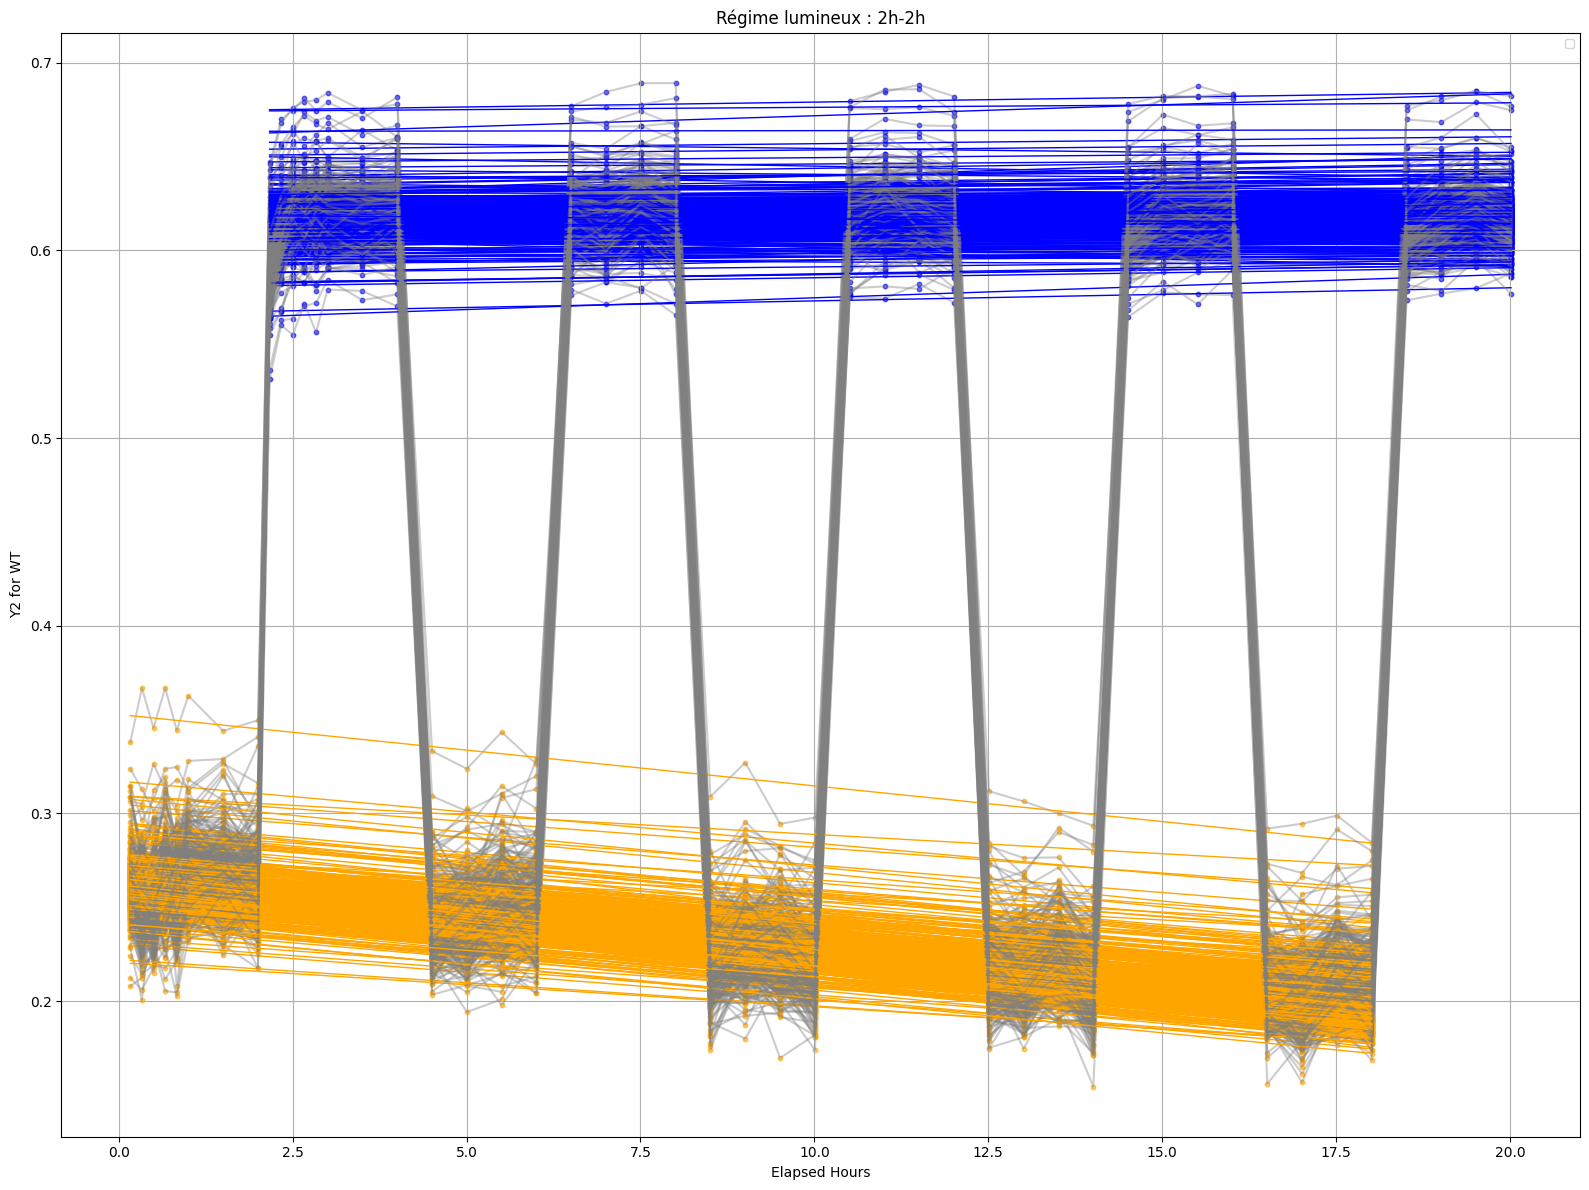

In [11]:
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
light_status_cols = [col for col in data.columns if col.startswith('light_status_')]

for col in time_columns:
    data[col] = pd.to_datetime(data[col], format='mixed')

elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]

data = data.drop(columns=[col for col in data.columns if col.startswith("elapsed_hours_")], errors='ignore')
data = pd.concat([data, elapsed_hours], axis=1)

elapsed_hours_cols = sorted(
    [col for col in data.columns if col.startswith("elapsed_hours_")],
    key=lambda x: int(x.split("_")[-1])
)

light_regimes = [light]  # définir light ailleurs
fig, axes = plt.subplots(1, figsize=(16, 12))
axes = [axes]

for i, light in enumerate(light_regimes):
    ax = axes[i]
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith(plate))]

    for plate in data_light['plate'].unique():
        data_plate = data_light[
            (data_light['mutant_ID'].isin(['WT', 'WT CLiP'])) &
            (data_light['plate'] == plate)
        ]

        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].astype(float).values
            time_values = row[elapsed_hours_cols[1:]].astype(float).values
            light_status = row[light_status_cols[1:]].astype(str).values

            valid = ~np.isnan(time_values) & ~np.isnan(y2_values) & pd.notna(light_status)
            time_values = time_values[valid]
            y2_values = y2_values[valid]
            light_status = light_status[valid]

            ax.plot(time_values, y2_values, alpha=0.4, color='gray')
            ax.scatter(time_values[light_status == 'light'], y2_values[light_status == 'light'], color='orange', s=10, alpha=0.6)
            ax.scatter(time_values[light_status == 'dark'], y2_values[light_status == 'dark'], color='blue', s=10, alpha=0.6)

            for condition, color in zip(['light', 'dark'], ['orange', 'blue']):
                cond_mask = light_status == condition
                if cond_mask.sum() >= 2:
                    x = time_values[cond_mask].reshape(-1, 1)
                    y = y2_values[cond_mask]
                    model = LinearRegression().fit(x, y)
                    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
                    y_line = model.predict(x_line)
                    ax.plot(x_line, y_line, color=color, linewidth=1)

    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel('Y2 for WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

data['y2_slope_light'] = np.nan
data['y2_slope_dark'] = np.nan

y2_cols = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
elapsed_cols = [col.replace('y2_', 'elapsed_hours_') for col in y2_cols]
light_status_cols = [col.replace('y2_', 'light_status_') for col in y2_cols]

# Sanity check: assure que les colonnes existent
cols_exist = all(col in data.columns for col in elapsed_cols + light_status_cols)
if not cols_exist:
    raise ValueError("Certaines colonnes elapsed_hours_ ou light_status_ sont manquantes.")

# Parcourir chaque ligne
for idx, row in data.iterrows():
    y2_values = row[y2_cols].values.astype(float)
    time_values = row[elapsed_cols].values.astype(float)
    light_status = row[light_status_cols].values

    valid = ~np.isnan(y2_values) & ~np.isnan(time_values) & pd.notna(light_status)
    y2_values = y2_values[valid]
    time_values = time_values[valid]
    light_status = light_status[valid]

    if len(y2_values) < 2:
        continue

    # Régression sur les points "light"
    mask_light = light_status == 'light'
    if np.sum(mask_light) >= 2:
        x = time_values[mask_light].reshape(-1, 1)
        y = y2_values[mask_light]
        model = LinearRegression().fit(x, y)
        data.at[idx, 'y2_slope_light'] = model.coef_[0]

    # Régression sur les points "dark"
    mask_dark = light_status == 'dark'
    if np.sum(mask_dark) >= 2:
        x = time_values[mask_dark].reshape(-1, 1)
        y = y2_values[mask_dark]
        model = LinearRegression().fit(x, y)
        data.at[idx, 'y2_slope_dark'] = model.coef_[0]

In [7]:
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv', index=False)